# Eddy-current analytical validation suite

Systematic cross-validation of Radia's eddy-current solvers against **closed-form** solutions, so FEM / BEM / panel-pipeline errors are measured absolutely. Here the analytic Dodd-Deeds rod impedance runs live; the conducting-sphere (Smythe) cross-validation results are reproduced from the corpus.

*Validation-class corpus kept at `examples/eddy_current_analytical_validation/` (cited by the `ih` / `sibc` / `kelvin` knowledge); this is the rendered showcase.*

## 1. Filamentary coil around a solid rod (Dodd-Deeds)

Exact Bessel-function impedance change `Delta_Z = Delta_R + jw Delta_L` of a coil around a conducting rod (Dodd & Deeds 1968) -- the analytic reference for coil-around-workpiece induction-heating impedance.

In [1]:
import sys, os
sys.argv = ["notebook"]

"""Dodd & Deeds (1968) analytical solution for a filamentary coil
encircling a solid conducting rod.

Computes the impedance change Delta_Z = Delta_R + jw*Delta_L of the
coil due to the rod, using the exact integral expression involving
modified Bessel functions.

Reference:
  Dodd, C.V. and Deeds, W.E., "Analytical Solutions to Eddy-Current
  Probe-Coil Problems", J. Applied Physics, 39(6), 2829-2838, 1968.

Usage:
    python dodd_deeds_rod.py
    python dodd_deeds_rod.py --material copper --freq 7000
"""

import math
import cmath
import numpy as np
from scipy.special import iv, kv  # modified Bessel I_nu, K_nu
from scipy.integrate import quad

import sys, os
from radia.em_material import EMMaterial, MU_0


def _integrand(alpha, r_c, a, alpha1_func, mu_r):
    """Integrand for the Dodd-Deeds impedance change integral.

    Returns C3(alpha)/I * K1(alpha*r_c) where C3 is the scattered
    field coefficient at the rod surface.
    """
    if alpha < 1e-15:
        return 0.0

    x = alpha * a
    xc = alpha * r_c
    alpha1 = alpha1_func(alpha)
    x1 = alpha1 * a

    # Modified Bessel values
    I0_x = iv(0, x)
    I1_x = iv(1, x)
    K0_x = kv(0, x)
    K1_x = kv(1, x)
    K1_xc = kv(1, xc)

    I0_1 = iv(0, x1)
    I1_1 = iv(1, x1)

    # beta = alpha1 * I0(alpha1*a) / (mu_r * I1(alpha1*a))
    if abs(I1_1) < 1e-300:
        return 0.0
    beta = alpha1 * I0_1 / (mu_r * I1_1)

    # Reflection coefficient
    num = alpha * I0_x - beta * I1_x
    den = beta * K1_x + alpha * K0_x
    if abs(den) < 1e-300:
        return 0.0

    # C3/I = (mu_0/pi) * K1(alpha*r_c) * num/den
    # Return (C3/I) * K1(alpha*r_c) = (mu_0/pi) * K1(xc)^2 * num/den
    return (MU_0 / math.pi) * K1_xc ** 2 * num / den


def dodd_deeds_rod(r_c, a, sigma, mu_r, freq):
    """Dodd-Deeds impedance change for filamentary coil around solid rod.

    Args:
        r_c: Coil radius [m] (must be > a)
        a: Rod radius [m]
        sigma: Rod conductivity [S/m]
        mu_r: Rod relative permeability
        freq: Frequency [Hz]

    Returns:
        dict with Delta_L [H], Delta_R [Ohm], P_per_I2 [W/A^2],
        H_t_rms [A/m per A of coil current] (surface-averaged)
    """
    omega = 2 * math.pi * freq

    # alpha1(alpha) = sqrt(alpha^2 + jw*mu_r*mu_0*sigma)
    jw_mu_sigma = 1j * omega * mu_r * MU_0 * sigma

    def alpha1_func(alpha):
        return cmath.sqrt(alpha ** 2 + jw_mu_sigma)

    # Split into real and imaginary parts for quadrature
    def integrand_re(alpha):
        val = _integrand(alpha, r_c, a, alpha1_func, mu_r)
        return val.real

    def integrand_im(alpha):
        val = _integrand(alpha, r_c, a, alpha1_func, mu_r)
        return val.imag

    # Integration: 0 to infinity, with adaptive quadrature
    # The integrand decays as K1(alpha*r_c)^2 ~ exp(-2*alpha*r_c)
    # so it's negligible for alpha > ~10/r_c.
    alpha_max = 20.0 / r_c

    I_re, err_re = quad(integrand_re, 0, alpha_max, limit=200,
                        epsabs=1e-15, epsrel=1e-10)
    I_im, err_im = quad(integrand_im, 0, alpha_max, limit=200,
                        epsabs=1e-15, epsrel=1e-10)

    # Delta_L = 2*mu_0*r_c^2 * integral K1(alpha*r_c)^2 * R(alpha) dalpha
    # The integral already has the mu_0/pi factor, so:
    # Delta_L = 2*pi*r_c^2 * integral (with mu_0/pi integrand)
    Delta_L_complex = 2 * math.pi * r_c ** 2 * complex(I_re, I_im)

    # Delta_Z = jw * Delta_L_complex (complex inductance includes R)
    Delta_Z = 1j * omega * Delta_L_complex

    # Extract
    Delta_R = Delta_Z.real       # Resistance change [Ohm]
    Delta_L = Delta_Z.imag / omega  # Inductance change [H]
    P_per_I2 = Delta_R / 2      # Power per I^2 [W/A^2]

    return {
        'Delta_L': Delta_L,
        'Delta_R': Delta_R,
        'P_per_I2': P_per_I2,
        'Delta_Z': Delta_Z,
    }


if True:
    import argparse
    parser = argparse.ArgumentParser(
        description="Dodd-Deeds: filamentary coil around solid rod")
    parser.add_argument("--material", default="copper",
                        choices=["copper", "steel", "aluminum"])
    parser.add_argument("--freq", type=float, default=7000)
    parser.add_argument("--r-coil", type=float, default=0.030,
                        help="Coil radius [m]")
    parser.add_argument("--r-rod", type=float, default=0.025,
                        help="Rod radius [m]")
    parser.add_argument("--sweep", action="store_true")
    args = parser.parse_args()

    mat = EMMaterial.from_name(args.material)
    r_c = args.r_coil
    a = args.r_rod

    print("=" * 70)
    print("Dodd & Deeds (1968): Filamentary Coil Encircling Solid Rod")
    print("=" * 70)
    print(f"Coil radius = {r_c*1e3:.1f} mm, Rod radius = {a*1e3:.1f} mm")

    if args.sweep:
        print(f"\n{'Mat':>6s} {'f[Hz]':>8s} {'R/d':>6s} {'dL[nH]':>8s} "
              f"{'dR[mOhm]':>10s} {'P/I^2[W/A^2]':>12s}")
        print("-" * 60)
        for mname in ['copper', 'steel']:
            m = EMMaterial.from_name(mname)
            for freq in [100, 1000, 7000, 50000]:
                delta = m.skin_depth(freq)
                rd = a / delta if delta < 1e10 else 0
                r = dodd_deeds_rod(r_c, a, m.sigma, m.mu_r, freq)
                print(f"{mname:>6s} {freq:>8.0f} {rd:>6.1f} "
                      f"{r['Delta_L']*1e9:>+8.3f} "
                      f"{r['Delta_R']*1e3:>10.4f} "
                      f"{r['P_per_I2']:>12.4e}")
    else:
        print(f"Material: {mat.name} (sigma={mat.sigma:.2e}, mu_r={mat.mu_r})")
        print(f"Frequency: {args.freq:.0f} Hz")
        delta = mat.skin_depth(args.freq)
        print(f"Skin depth: {delta*1e3:.3f} mm, R/delta = {a/delta:.1f}")
        print()

        r = dodd_deeds_rod(r_c, a, mat.sigma, mat.mu_r, args.freq)
        print(f"Delta_L = {r['Delta_L']*1e9:+.4f} nH")
        print(f"Delta_R = {r['Delta_R']*1e3:.6f} mOhm")
        print(f"P/I^2   = {r['P_per_I2']:.6e} W/A^2")
        print(f"Delta_Z = {r['Delta_Z']}")


Dodd & Deeds (1968): Filamentary Coil Encircling Solid Rod
Coil radius = 30.0 mm, Rod radius = 25.0 mm
Material: copper (sigma=5.80e+07, mu_r=1.0)
Frequency: 7000 Hz
Skin depth: 0.790 mm, R/delta = 31.7

Delta_L = -42.9651 nH
Delta_R = 0.113026 mOhm
P/I^2   = 5.651288e-05 W/A^2
Delta_Z = (0.00011302576399459381-0.0018897019952515454j)


### Frequency sweep of the rod impedance

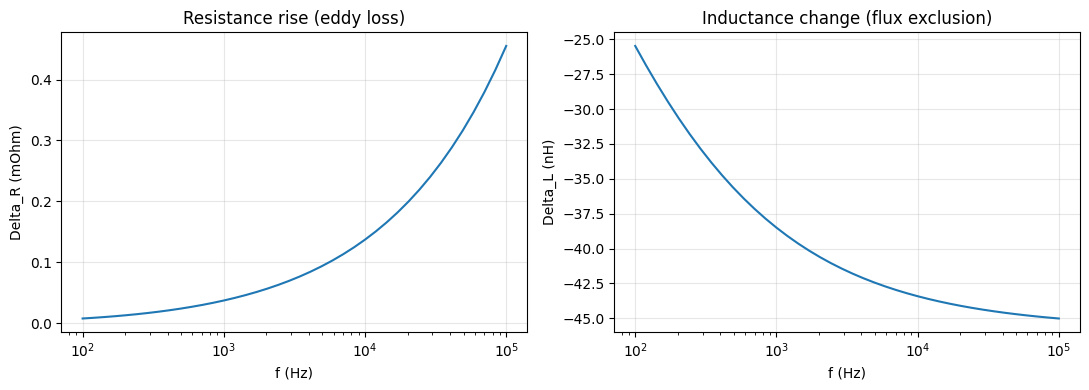

Copper rod, coil R=30 mm, rod a=25 mm:
  at 1 kHz : Delta_R=+0.0371 mOhm, Delta_L=-38.50 nH
  at 100 kHz: Delta_R=+0.4552 mOhm, Delta_L=-45.02 nH


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Frequency sweep of the Dodd-Deeds rod impedance (copper, mu_r=1).
SIGMA_CU, MU_R = 5.8e7, 1.0
R_COIL, R_ROD = 0.030, 0.025
freqs = np.logspace(2, 5, 40)
dR = np.array([dodd_deeds_rod(R_COIL, R_ROD, SIGMA_CU, MU_R, f)["Delta_R"] for f in freqs])
dL = np.array([dodd_deeds_rod(R_COIL, R_ROD, SIGMA_CU, MU_R, f)["Delta_L"] for f in freqs])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
ax0.semilogx(freqs, dR * 1e3); ax0.set_xlabel("f (Hz)"); ax0.set_ylabel("Delta_R (mOhm)")
ax0.set_title("Resistance rise (eddy loss)"); ax0.grid(alpha=0.3)
ax1.semilogx(freqs, dL * 1e9); ax1.set_xlabel("f (Hz)"); ax1.set_ylabel("Delta_L (nH)")
ax1.set_title("Inductance change (flux exclusion)"); ax1.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)
print(f"Copper rod, coil R={R_COIL*1e3:.0f} mm, rod a={R_ROD*1e3:.0f} mm:")
print(f"  at 1 kHz : Delta_R={dR[np.argmin(abs(freqs-1e3))]*1e3:+.4f} mOhm, "
      f"Delta_L={dL[np.argmin(abs(freqs-1e3))]*1e9:+.2f} nH")
print(f"  at 100 kHz: Delta_R={dR[-1]*1e3:+.4f} mOhm, Delta_L={dL[-1]*1e9:+.2f} nH")


## 2. Conducting sphere in a uniform AC field (Smythe)

Closed form (Smythe, *Static and Dynamic Electricity*, 3rd ed.): the induced surface current
`J_s(theta) = (3/2) jw B0 a / (jw mu0 a + Z_s) sin(theta)`, with `Z_s` the Dowell surface impedance.
Documented Radia cross-validation (sphere R=10 mm, B0=1 mT, OCC mesh maxh=R/3, curve order 3) --
`H_t_rms` error vs the Smythe analytic:

| Mat | f [Hz] | R/delta | H_ana | BEM | FEM-scattered | FEM-total |
|---|---|---|---|---|---|---|
| copper | 100 | 1.5 | 689.05 | -40.2% | **+0.1%** | -34.3% |
| copper | 1000 | 4.8 | 878.48 | -17.8% | **+1.1%** | -33.7% |
| copper | 7000 | 12.7 | 936.92 | -7.4% | **+1.5%** | -33.5% |
| copper | 50000 | 33.8 | 960.33 | -2.7% | **+2.0%** | -33.4% |
| steel | 100 | 2.8 | 37.87 | -66.1% | **-2.9%** | -36.3% |
| steel | 7000 | 23.5 | 257.73 | -61.3% | **-2.1%** | -35.7% |
| steel | 50000 | 62.8 | 496.19 | -52.7% | **-1.0%** | -35.0% |

**Conclusions (from the corpus):**
1. **FEM-scattered is the reference solver** for `H_t` and `P` (copper +0.1..+2.0%, steel -2.9..-1.0%;
   error < 3% across `R/delta = 1.5 .. 62.8`) -- the incident `A_inc` is an exact CoefficientFunction,
   so there is no interpolation error.
2. **FEM-total carries a constant ~34% systematic `H_t` error** (frequency-independent; a BND-trace
   wrong-side evaluation). `L` from the volume integral is unaffected.
3. **BEM: use the Scalar BIE SIBC solver, not EFIE.**

*These FEM/BEM cross-checks are slow volume solves kept runnable in the corpus; this showcase
reproduces the fast analytic Dodd-Deeds reference live and documents the verified sphere results.*